# bike rental training assignment
# Name: Mohammad Uzair
# Student Id: 2025AC05743

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split

# RMSLE — exactly the function the assignment gives you
def rmsle(y_true, y_pred):
    y_pred = np.maximum(y_pred, 0)        # counts can't be negative
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true))**2))

In [51]:



## load file and analyze data
import pandas as pd
import numpy as np

train = pd.read_csv("./data/bike_train.csv")
test = pd.read_csv("./data/bike_test.csv")

# Train is year-first
train["datetime"] = pd.to_datetime(train["datetime"])
# Test is DAY-first (05-06-2012 = 5th June)
test["datetime"]  = pd.to_datetime(test["datetime"], dayfirst=True)

# Keep test datetimes aside now — the submission file needs
test_ids = test["datetime"].copy()

# data exploratory analysis
print(f"training shape", train.shape)
print(f"test shape", test.shape)
print(f"Training columns\n", train.columns)
print(f"Test columns\n", test.columns)

print(f"training data types\n", train.dtypes)
print(f"test data types\n", test.dtypes) # raw dtypes

print(f"Null values\n",train.isnull().sum())            # missing values per column
train.describe()

training shape (10450, 12)
test shape (2613, 9)
Training columns
 Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count'],
      dtype='str')
Test columns
 Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed'],
      dtype='str')
training data types
 datetime      datetime64[us]
season                 int64
holiday                int64
workingday             int64
weather                int64
temp                 float64
atemp                float64
humidity               int64
windspeed            float64
casual                 int64
registered             int64
count                  int64
dtype: object
test data types
 datetime      datetime64[us]
season                 int64
holiday                int64
workingday             int64
weather                int64
temp                 float64
atemp                float64
humidity        

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10450,10450.000000,10450.000000,10450.000000,10450.000000,10450.000000,10450.000000,10450.000000,10450.000000,10450.000000,10450.000000,10450.000000
mean,2011-12-26 18:06:50.826507,2.507943,0.028804,0.675694,1.413876,20.191700,23.605793,61.924211,12.765259,35.869091,154.511675,190.410526
min,2011-01-01 00:00:00,1.000000,0.000000,0.000000,1.000000,0.820000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2011-07-01 14:15:01.500000,2.000000,0.000000,0.000000,1.000000,13.940000,16.665000,47.000000,7.001500,4.000000,35.000000,42.000000
50%,2012-01-01 08:30:00.500000,3.000000,0.000000,1.000000,1.000000,20.500000,24.240000,62.000000,12.450050,16.000000,117.000000,143.000000
75%,2012-07-02 02:30:00.750000,4.000000,0.000000,1.000000,2.000000,26.240000,31.060000,77.000000,16.997900,49.000000,221.000000,283.000000
max,2012-12-19 23:00:00,4.000000,1.000000,1.000000,4.000000,41.000000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000
std,NaN,1.116946,0.167263,0.468137,0.632258,7.792683,8.478045,19.245193,8.102821,49.629436,150.861267,181.038755


# Question 1.

training shape (10450, 12) </br>
test shape (2613, 9)
1. 3 columns are missing in test data, count will be predicted, however, casual and registered is not part of test data, so no need to include in the feature for training
2. <b>datetime </b> will decompose this column into 4 new features - hour,day,month and year
3. <b>datetime </b> date format is different in training and test, will have to create the same format
4.There are no null value



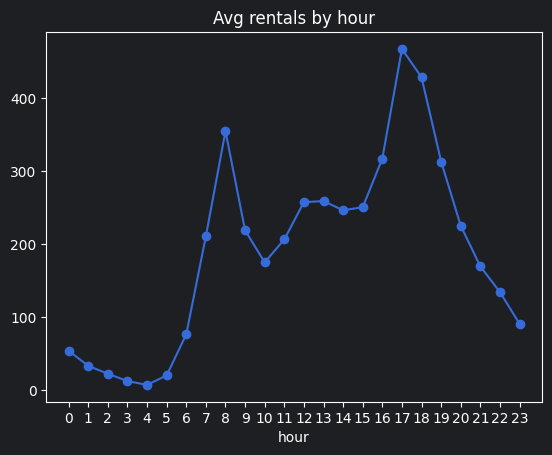

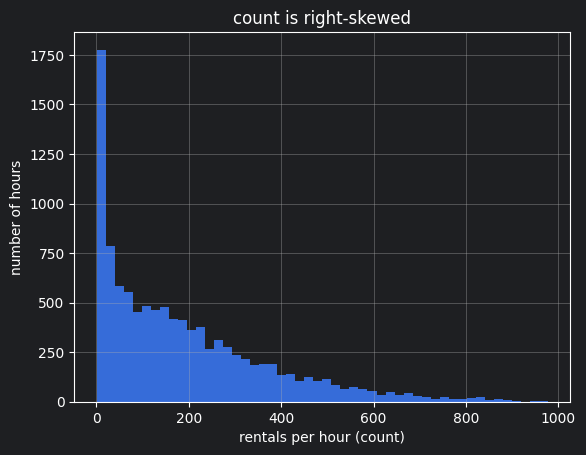

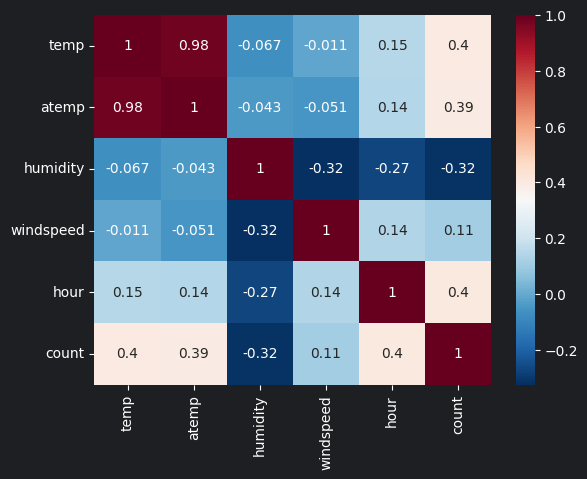

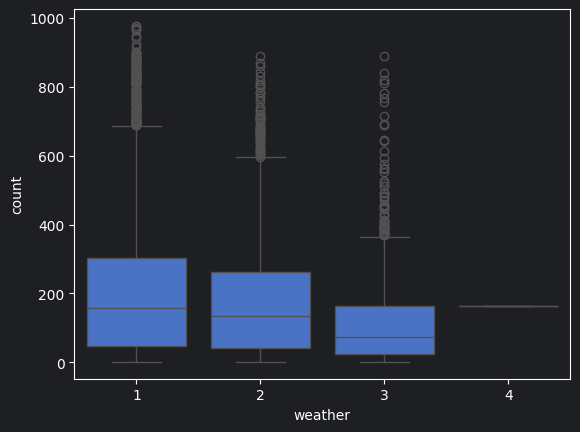

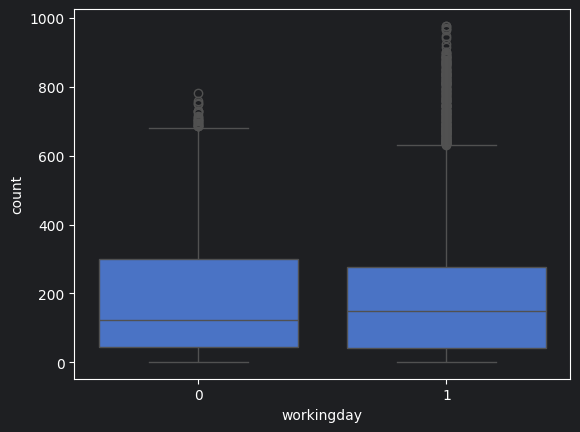

In [52]:
## Solution to Question 2
train["hour"]  = train["datetime"].dt.hour
train["month"] = train["datetime"].dt.month
train["dow"]   = train["datetime"].dt.dayofweek   # 0=Mon

# 1) Demand by hour — the headline plot a
train.groupby("hour")["count"].mean().plot(marker="o")
plt.xticks(range(24))
plt.title("Avg rentals by hour"); plt.show()

# 2) Target distribution — shows the skew that motivates log1p
train["count"].hist(bins=50)
plt.xlabel("rentals per hour (count)")
plt.ylabel("number of hours")
plt.title("count is right-skewed")
plt.show()


# 3) Correlation heatmap (numeric only)
num = ["temp","atemp","humidity","windspeed","hour","count"]
sns.heatmap(train[num].corr(), annot=True, cmap="RdBu_r"); plt.show()

# 4) Boxplots vs categorical
sns.boxplot(x="weather", y="count", data=train); plt.show()
sns.boxplot(x="workingday", y="count", data=train); plt.show()

## Question 2 & 3

Observations from visualization

1. Plot 1 -> shows rental count across hours, two peaks, one in the morning between 7 to 9 and another in the evening 6 to 8pm.
2. The pattern is non linear, a straight line will miss peaks and humps with huge margins.
3. <b>Hour</b> is the most important feature which effects the demand.
4. Plot 2 -> histogram of counts vs number of hours. 0-20 rentals has the maximum frequency in the data set (~1750), and on the far right 800 to 1000 rentals is rare. These rare values cause huge squared error and pull the model towards the spikes. We use log1p to regularize the count.
5. Heat Map observations
6. temp is 0.40, strongest signal
6. temp and atemp is almost similar
7. windspeed - 0.11, very week
8. humidity - -0.32, shows when humidity increases, rental drops
9. Observations from boxplots
10. weather impacts the rentals, there is nothing for weather 4, for 1 and 2, median is high
11.
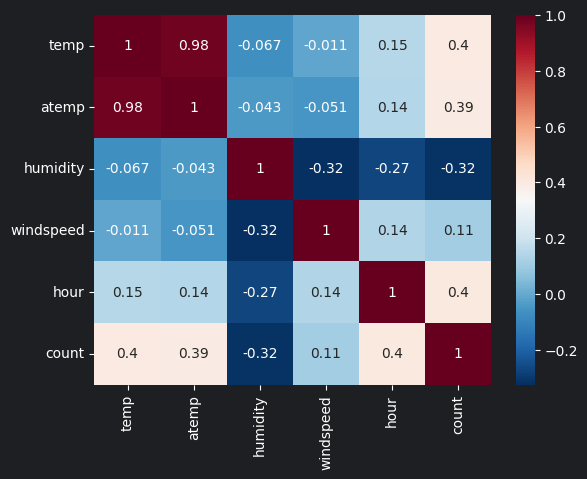

In [53]:
## Question 4
## feature engineering, adding new features

def add_features(df):
    df = df.copy()
    df["hour"]  = df["datetime"].dt.hour
    df["month"] = df["datetime"].dt.month
    df["year"]  = df["datetime"].dt.year
    df["dow"]   = df["datetime"].dt.dayofweek

    # Cyclical hour encoding: midnight (23h) and 0h are neighbours, not opposites
    df["hour_sin"] = np.sin(2*np.pi*df["hour"]/24)
    df["hour_cos"] = np.cos(2*np.pi*df["hour"]/24)
    return df

train = add_features(train)
test  = add_features(test)

# One-hot the true categoricals, align columns across train/test
cat = ["season","weather"]
train = pd.get_dummies(train, columns=cat)
test  = pd.get_dummies(test,  columns=cat)
train, test = train.align(test, join="left", axis=1, fill_value=0)

drop = ["datetime","casual","registered","count"]
features = [c for c in train.columns if c not in drop]



# Feature Engineering

1. Converted datetime to 4 new features - hour, month, year, dow. These will be important features since the train data heavely dependent on hours of the day, month for season, year and dow for working and weekends
2. Dropped datetime (already broken into 4 new features), casual, registered and count(not needed for X)

In [60]:
# Regression Q5 and Q6
from IPython.display import Markdown, display


X = train[features]
y = np.log1p(train["count"])

X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42)

lin = LinearRegression().fit(X_tr, y_tr)

# invert the log before scoring against true counts
pred_val = np.expm1(lin.predict(X_val))
true_val = np.expm1(y_val)
print("Linear RMSLE:", rmsle(true_val, pred_val))

compare = pd.DataFrame({
    "actual": true_val.values,
    "predicted": pred_val.round().astype(int)
})
display(Markdown(compare.head(20).to_markdown()))


Linear RMSLE: 0.8257307873709402


|    |   actual |   predicted |
|---:|---------:|------------:|
|  0 |        3 |           7 |
|  1 |        4 |          33 |
|  2 |      286 |         195 |
|  3 |       75 |         120 |
|  4 |      148 |         103 |
|  5 |      122 |         246 |
|  6 |      283 |         201 |
|  7 |      296 |          71 |
|  8 |      484 |         349 |
|  9 |      162 |         154 |
| 10 |       26 |          33 |
| 11 |      102 |         121 |
| 12 |       65 |          57 |
| 13 |       44 |          45 |
| 14 |      361 |         364 |
| 15 |        1 |          18 |
| 16 |       26 |          41 |
| 17 |      478 |         298 |
| 18 |       31 |          13 |
| 19 |        7 |          45 |

# linear regression

1. Linear RMSLE: 0.8257307873709402
2. exp(0.826) ≈ 2.28
3. Prediction is off by 2.28 factor


In [55]:
## Q6
def make_model(estimator):
    return make_pipeline(
        StandardScaler(),
        PolynomialFeatures(degree=2, include_bias=False),
        estimator)

results = {}
for name, est in {
        "Poly2 + Linear": LinearRegression(),
        "Poly2 + Ridge" : Ridge(),
        "Poly2 + Lasso" : Lasso(max_iter=5000)}.items():
    m = make_model(est).fit(X_tr, y_tr)
    p = np.expm1(m.predict(X_val))
    results[name] = rmsle(np.expm1(y_val), p)

# Tune the regularization strength alpha for Ridge
for a in [0.01, 0.1, 1, 10, 100]:
    m = make_model(Ridge(alpha=a)).fit(X_tr, y_tr)
    p = np.expm1(m.predict(X_val))
    print("Ridge alpha", a, "->", rmsle(np.expm1(y_val), p))


Ridge alpha 0.01 -> 0.5626993846841146
Ridge alpha 0.1 -> 0.5725301916514814
Ridge alpha 1 -> 0.5811619178933003
Ridge alpha 10 -> 0.5837156195883147
Ridge alpha 100 -> 0.5887145061169997


In [56]:
## Q7

pd.DataFrame(results.items(), columns=["Model","RMSLE"]) \
  .sort_values("RMSLE")

,Model,RMSLE
0,Poly2 + Linear,0.561890
1,Poly2 + Ridge,0.581162
2,Poly2 + Lasso,1.424872


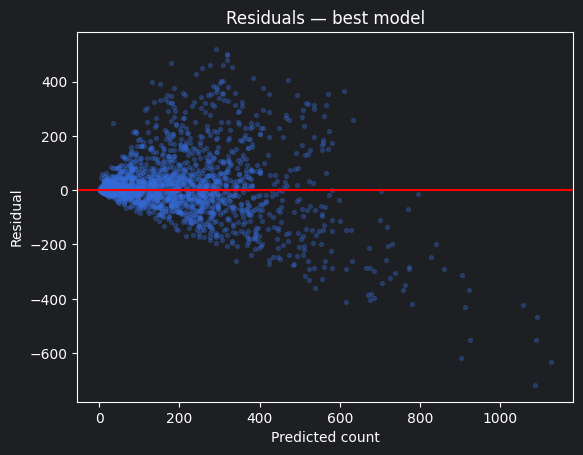

In [57]:
## Q8

best = make_model(Ridge(alpha=1.0)).fit(X_tr, y_tr)   # use your winning alpha
pred = np.expm1(best.predict(X_val))
resid = np.expm1(y_val) - pred

plt.scatter(pred, resid, s=8, alpha=0.3)
plt.axhline(0, color="red")
plt.xlabel("Predicted count"); plt.ylabel("Residual")
plt.title("Residuals — best model"); plt.show()

# Q9

1. Log target aligns training with the RMSLE metric and tames the skew, so large-count hours stop dominating the loss.
2. Polynomial features give the model the curvature it needs to approximate non-linear effects (temperature comfort zone, hour interactions) that a straight line cannot.
3. Tuned regularization counteracts the variance that degree-2 expansion introduces. Ridge shrinks the inflated coefficients, so the model fits signal instead of noise and generalizes to the validation set

# Q10

RMSLE = √( mean( (log(p+1) − log(a+1))² ) ) </br>
<p>The main thing here is that when we subtract two logs, it actually becomes a ratio instead of a normal difference. So RMSLE looks at the relative error, not the actual gap between the numbers. </p>
<p>For example, if the real value is 500 and we predict 450, thats only a 10% miss, so RMSLE sees this as a very small error. But RMSE only looks at the raw difference which is 50, and it treats a miss of 50 the same way whether the hour was busy or quiet. So RMSE would think this 50 is a big error even though its not really that bad. </p>
<p>Since the bike count data is right skewed and has a few very large values, RMSE would mostly get affected by those few huge hours. But RMSLE uses log so it squishes the big numbers down, which means missing a large count is punished much more gently compared to RMSE. </p>
<p>So basically RMSLE cares more about getting the right scale of the prediction everywhere, instead of trying to perfectly match the few very high peak values.</p>

# Q11

<p>A simple model (like our basic Linear Regression) is easy to understand, fast to train, and it doesnt overfit easily. The problem is that its too simple to capture complicated patterns, so it ends up underfitting. We saw this with the hour data where a straight line just cant follow the up and down demand during the day.</p>

<p>A more complex model (like adding polynomial features) can capture these harder non linear patterns and usually gives better accuracy. But the downside is that it can start memorizing the noise in the training data instead of the real pattern, which means it overfits. It also needs more data and more computation, and its harder to interpret.</p>

<p>This is basically the bias variance tradeoff. A simple model has high bias (underfits) and a complex model has high variance (overfits). So we cant just keep making the model more complex, because after a point the validation error starts going up again.</p>

<p>Thats why we use regularization like Ridge and Lasso. It lets us add more power to the model (the polynomial features) but still keeps the overfitting under control. So we get better predictions without paying the full price of overfitting. In the end the right choice depends on how much data we have, whether we need the model to be explainable, and how much accuracy we actually need.</p>

# Q12

<p>Linear Regression fits just one straight line, so it can only learn that as the hour goes up the count goes up or down in one direction. But the real demand doesnt work like that. It goes up in the morning around 8am, comes down in the afternoon, goes up again in the evening around 5-6pm, and then drops at night. A single straight line cant go up and down like this, so the model just averages everything out and misses all the peaks.</p>

<p>To fix this we can encode the hour using sin and cos so the model understands the daily cycle, or one hot encode each hour so every hour gets its own value, or add polynomial and interaction terms like workingday × hour so the line can bend and separate weekdays from weekends.</p>

In [58]:
# Exporting to submission file


final = make_model(Ridge(alpha=1.0)).fit(X, y)   # full train set

X_test = test[features]
test_pred = np.expm1(final.predict(X_test))
test_pred = np.maximum(test_pred, 0)            # no negative bikes

submission = pd.DataFrame({
    "datetime": test_ids,
    "Count_Predicted": test_pred.round().astype(int)})

submission.to_csv("Submission.csv", index=False)
submission.head()

,datetime,Count_Predicted
0,2012-06-05 05:00:00,20
1,2011-03-19 19:00:00,255
2,2012-04-02 06:00:00,52
3,2012-07-13 20:00:00,461
4,2011-11-09 19:00:00,265
